In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import  warnings 
warnings.filterwarnings("ignore") # hides unnecessary warning messages

# This line makes charts appear bigger and cleaner
plt.rcParams['figure.figsize']=(10,6)

print("All libaries imported successfully")

All libaries imported successfully


In [2]:
df=pd.read_csv("../data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print(f'data shape:{df.shape} data rows:{df.shape[0]} data columns:{df.shape[1]}')

data shape:(768, 9) data rows:768 data columns:9


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
# These columns cannot be zero in real life
# We count how many zeros exist in each
zero_columns=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
print("Zero values (hidden missing values) per columns:")
print("="*45)
for col in zero_columns:
    zero_count=(df[col]==0).sum()
    zero_percentage=(zero_count/len(df))*100
    print(f"{col:25}: {zero_count} zeros ({zero_percentage:.1f}%)")


Zero values (hidden missing values) per columns:
Glucose                  : 5 zeros (0.7%)
BloodPressure            : 35 zeros (4.6%)
SkinThickness            : 227 zeros (29.6%)
Insulin                  : 374 zeros (48.7%)
BMI                      : 11 zeros (1.4%)


Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

NO Diabetes (0): 500 patients (65.1%)
Has Diabetes (1): 268 patients (34.9%)


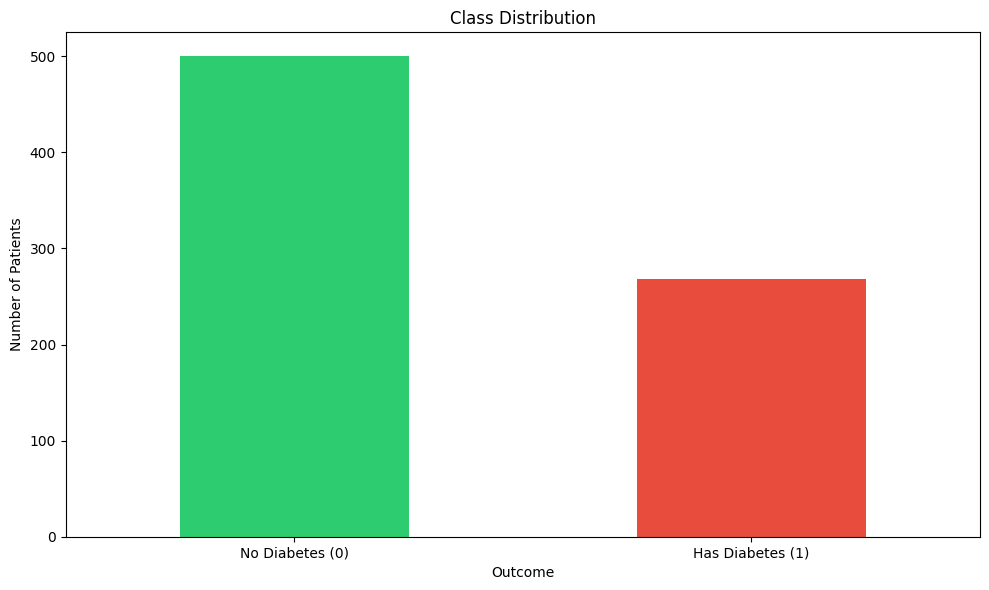

In [7]:
# Outcome is our target column — 0 = no diabetes, 1 = diabetes
# We check if both classes are balanced
print("Outcome distribution:")
print(df['Outcome'].value_counts())
print()
print(f"NO Diabetes (0): {(df['Outcome']==0).sum()} patients ({(df['Outcome']==0).mean()*100:.1f}%)")
print(f"Has Diabetes (1): {(df['Outcome']==1).sum()} patients ({(df['Outcome']==1).mean()*100:.1f}%)")

# Draw a bar chart
ax=df['Outcome'].value_counts().plot(kind='bar',color=['#2ecc71','#e74c3c'])
ax.set_xticklabels(['No Diabetes (0)', 'Has Diabetes (1)'],rotation=0)
plt.title('Class Distribution')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

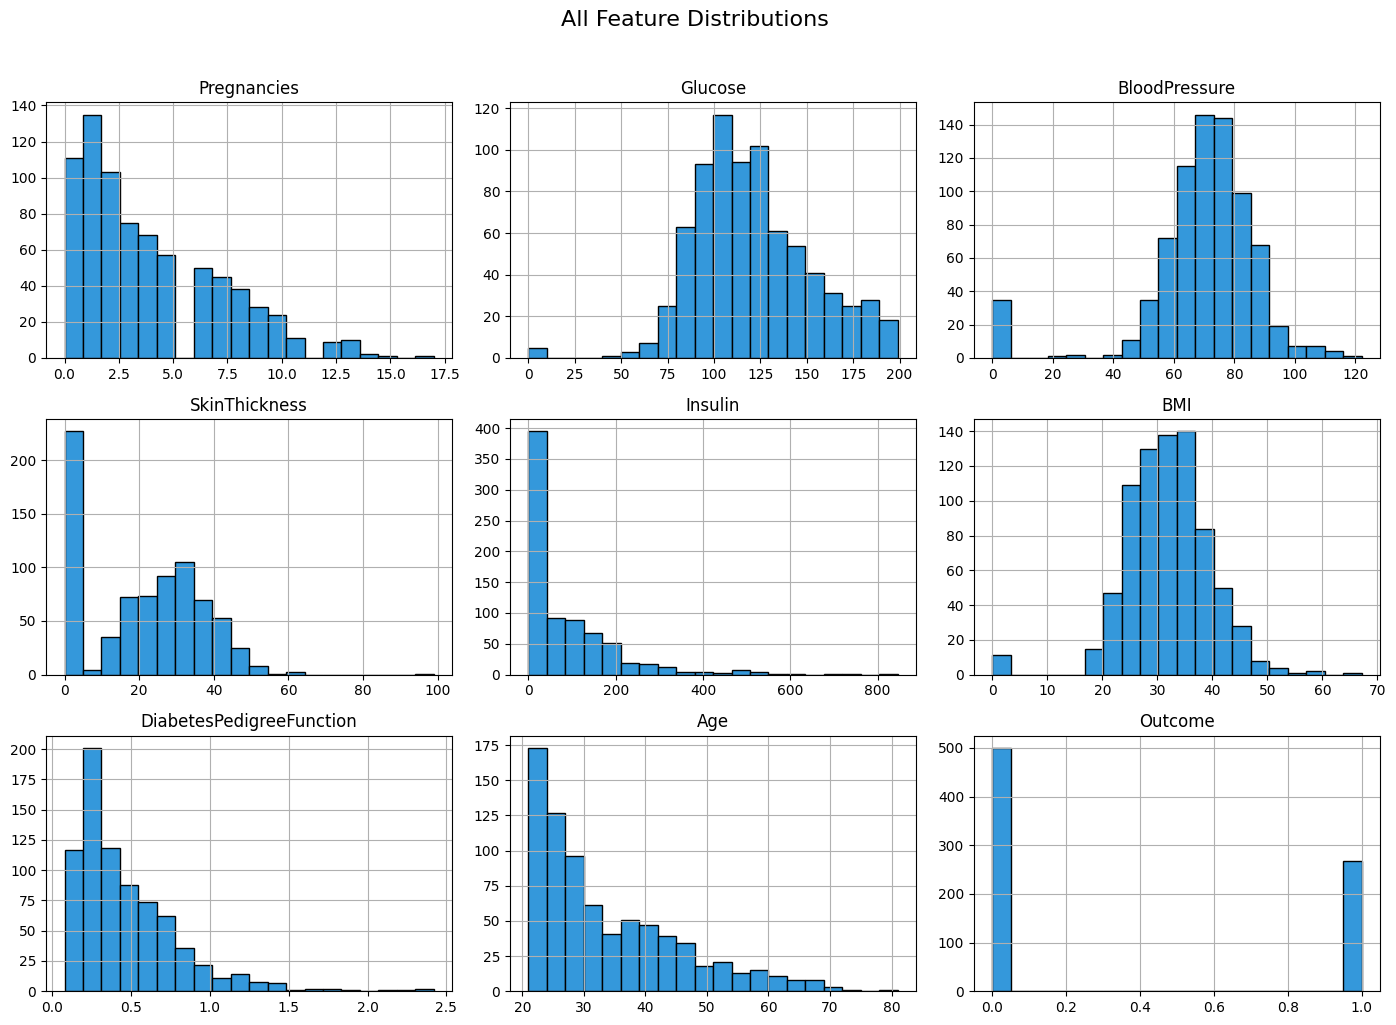

In [8]:
# Draw a histogram for every column
# This shows us the shape of each feature's data
df.hist(bins=20,figsize=(14,10), color='#3498db', edgecolor='black')
plt.suptitle('All Feature Distributions', fontsize=16,y=1.02)
plt.tight_layout()
plt.show()

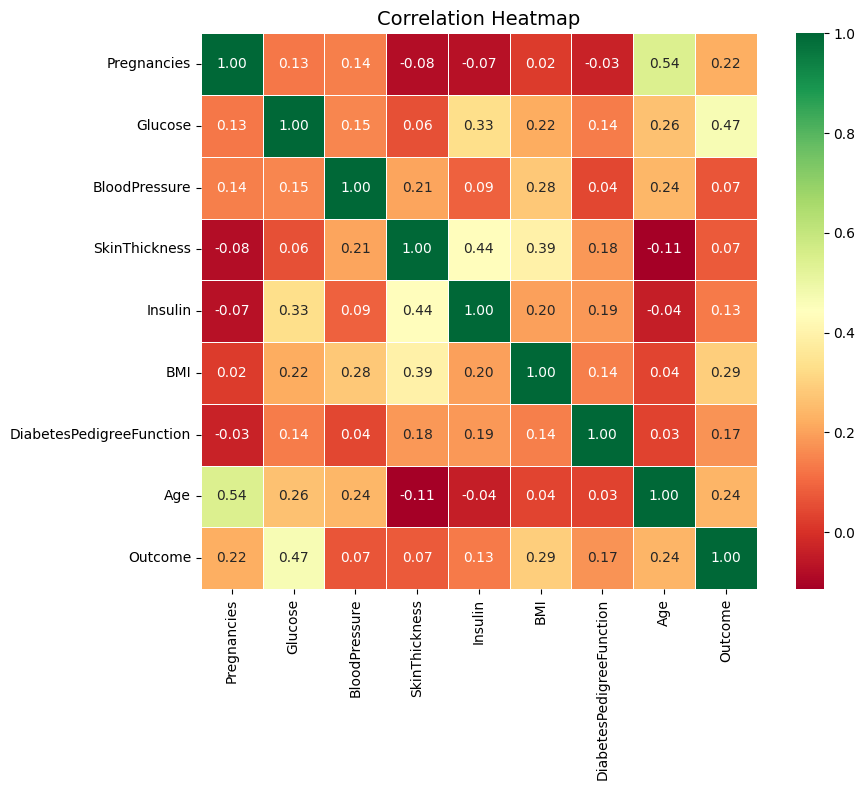

In [9]:
# Correlation tells us how strongly two columns move together
# Values close to 1 or -1 = strong relationship
# Values close to 0 = no relationship
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),
            annot=True, # show the numbers inside boxes
            fmt='.2f',  # round to 2 decimal places
            cmap='RdYlGn',  # red = negative, green = positive correlation
            linewidths=0.5,
            square=True)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

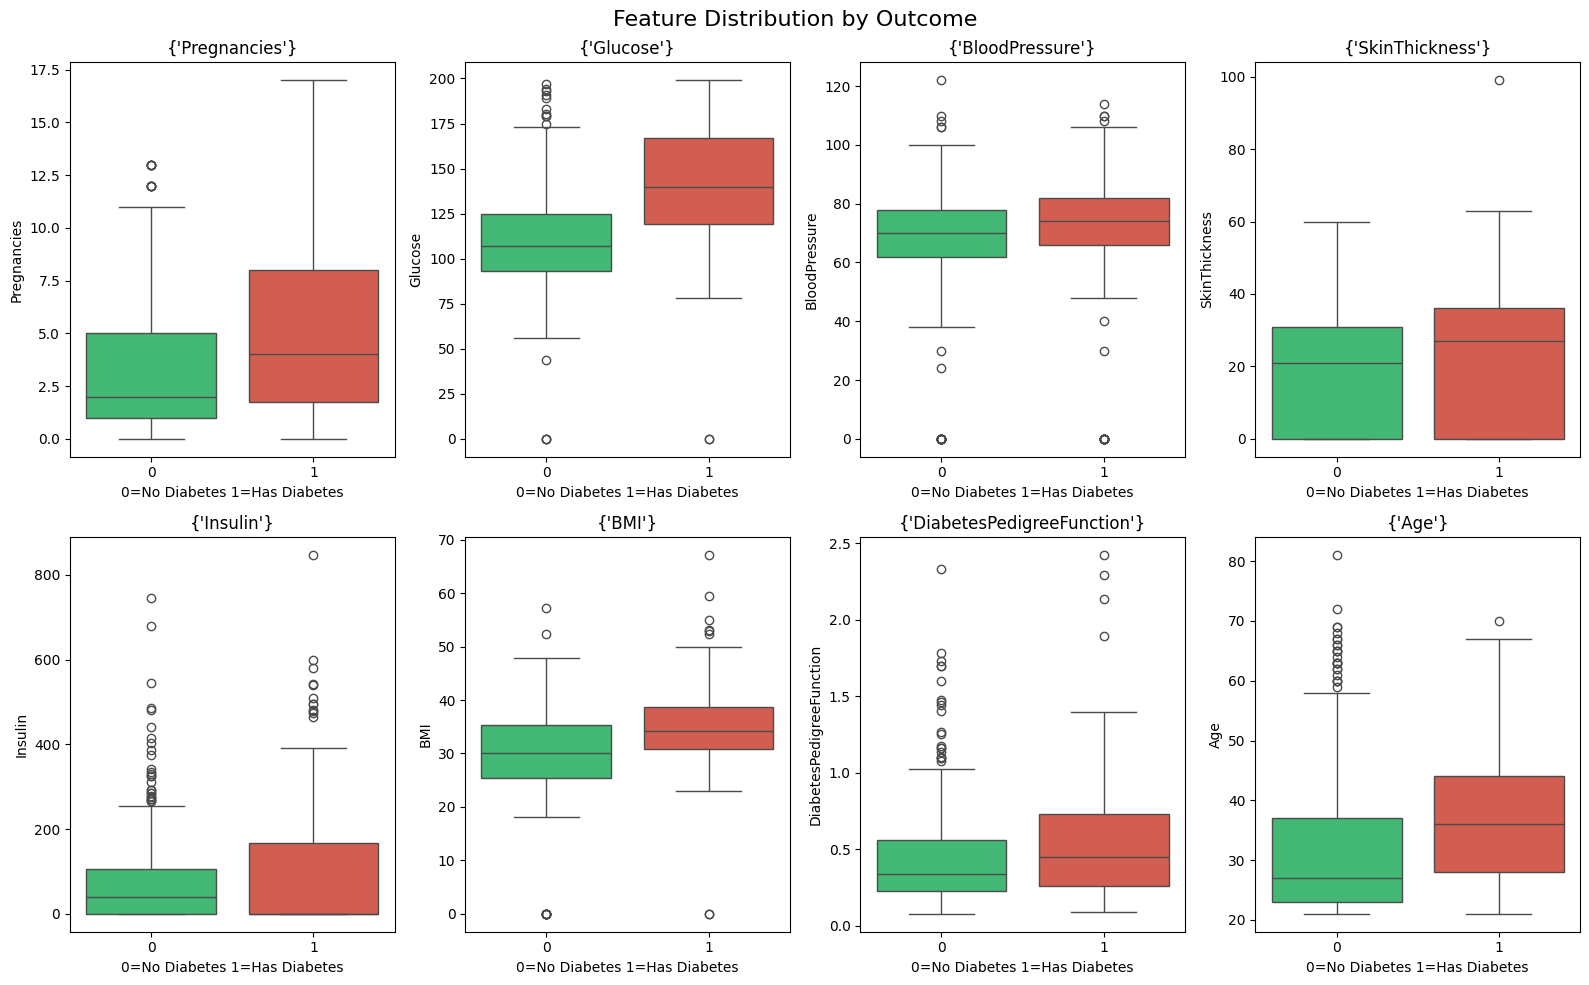

In [10]:
# A boxplot shows the spread of data and highlights outliers as dots
fig, axes=plt.subplots(2,4, figsize=(16,10))
axes=axes.flatten() # flatten 2D array to 1D for easy iteration
cols=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
for i, col in enumerate(cols):
    sns.boxplot(data=df, x='Outcome', y=col,
                palette=['#2ecc71','#e74c3c'], ax=axes[i])
    axes[i].set_title({col})
    axes[i].set_xlabel('0=No Diabetes 1=Has Diabetes')
    
plt.suptitle('Feature Distribution by Outcome', fontsize=16)
plt.tight_layout()
plt.show()
    